# Deep Gaussian Processes con GPFlux

## Deep Gaussian processes with Latent Variables

In this notebook, we explore the use of Deep Gaussian processes <cite data-cite="damianou2013deep"/> and Latent Variables to model a dataset with heteroscedastic noise. The model can be seen as a deep GP version of <cite data-cite="dutordoir2018cde"/> or as doing variational inference in models from <cite data-cite="salimbeni2019iwvi"/>. We start by fitting a single layer GP model to show that it doesn't result in a satisfactory fit for the noise.

This notebook is inspired by [prof. Neil Lawrence's Deep Gaussian process talk](https://inverseprobability.com/talks/notes/deep-gps.html), which we highly recommend watching.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

tf.get_logger().setLevel("INFO")

In [2]:
!pip install gpflow
!pip install gpflux

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 392.9/392.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.7/590.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 86.6 MB/s 

Text(0, 0.5, 'Acceleration')

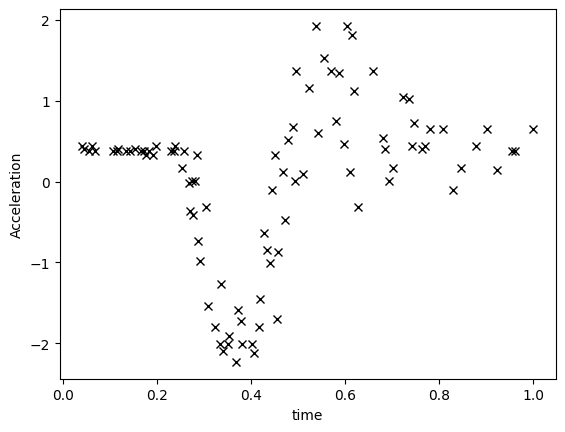

In [41]:
#load data
def motorcycle_data():
    """Return inputs and outputs for the motorcycle dataset. We normalise the outputs."""
    df = pd.read_csv("https://raw.githubusercontent.com/secondmind-labs/GPflux/develop/docs/notebooks/data/motor.csv", index_col=0)
    X, Y = df["times"].values.reshape(-1, 1), df["accel"].values.reshape(-1, 1)
    Y = (Y - Y.mean()) / Y.std()
    X /= X.max()
    return X, Y


X, Y = motorcycle_data()
plt.plot(X, Y, "kx")
plt.xlabel("time")
plt.ylabel("Acceleration")

##Single-layer GP
We start this introduction by building a single-layer GP using GPflux. However, you’ll notice that we rely a lot on GPflow objects to build our GPflux model. This is a conscious decision. GPflow contains well-tested and stable implementations of key GP building blocks, such as kernels, likelihoods, inducing variables, mean functions, and so on. By relying on GPflow for these elements, we can keep the GPflux code lean and focused on what is important for building deep GP models.

We are going to build a Sparse Variational Gaussian process (SVGP).

We start by importing gpflow and gpflux, and then create a kernel and inducing variable. Both are GPflow objects. We pass both objects to a GPLayer which will represent a single GP layer in our deep GP. We also need to specify the total number of datapoints and the number of outputs.

In [4]:
import gpflow
import gpflux

num_data = len(X)
num_inducing = 10
output_dim = Y.shape[1]

kernel = gpflow.kernels.SquaredExponential()
inducing_variable = gpflow.inducing_variables.InducingPoints(
    np.linspace(X.min(), X.max(), num_inducing).reshape(-1, 1)
)
gp_layer = gpflux.layers.GPLayer(
    kernel, inducing_variable, num_data=num_data, num_latent_gps=output_dim
)

/usr/local/lib/python3.11/dist-packages/gpflux/layers/gp_layer.py:175: UserWarning: Beware, no mean function was specified in the construction of the `GPLayer` so the default `gpflow.mean_functions.Identity` is being used. This mean function will only work if the input dimensionality matches the number of latent Gaussian processes in the layer.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gpflux/layers/gp_layer.py:198: UserWarning: Could not verify the compatibility of the `kernel`, `inducing_variable` and `mean_function`. We advise using `gpflux.helpers.construct_*` to create compatible kernels and inducing variables. As `num_latent_gps=1` has been specified explicitly, this will be used to create the `q_mu` and `q_sqrt` parameters.
  warnings.warn(


We now create a LikelihoodLayer which encapsulates a Likelihood from GPflow.

The likelihood layer is responsible for computing the variational expectation in the objective, and for dealing with our likelihood distribution. Other typical likelihoods are Softmax, RobustMax, and Bernoulli. Because we are dealing with the simple case of regression in this notebook, we use the Gaussian likelihood.

In [5]:
likelihood_layer = gpflux.layers.LikelihoodLayer(gpflow.likelihoods.Gaussian(0.1))

<ipython-input-5-dd90cca9c2f8>:1: DeprecationWarning: Call to deprecated class TrackableLayer. (GPflux's `TrackableLayer` was prior to TF2.5 used to collect GPflow variables in subclassed layers. As of TF 2.5, `tf.Module` supports this natively and there is no need for `TrackableLayer` anymore. It will be removed in GPflux version `1.0.0`.)
  likelihood_layer = gpflux.layers.LikelihoodLayer(gpflow.likelihoods.Gaussian(0.1))


 now, we pass our GP layer and likelihood layer into a GPflux DeepGP model. The DeepGP class is a specialisation of the Keras Model where we’ve added a few helper methods such as predict_f, predict_y, and elbo. By relying on Keras, we hope that users will have an easy time familiarising themselves with the GPflux API. Our DeepGP model has the same public API calls: fit, predict, evaluate, and so on.

In [20]:
single_layer_dgp = gpflux.models.DeepGP([gp_layer], likelihood_layer)
model = single_layer_dgp.as_training_model()
model.compile(gpflow.keras.tf_keras.optimizers.Adam(0.01))

We train the model by calling fit. Keras handles minibatching the data, and keeps track of our loss during training.

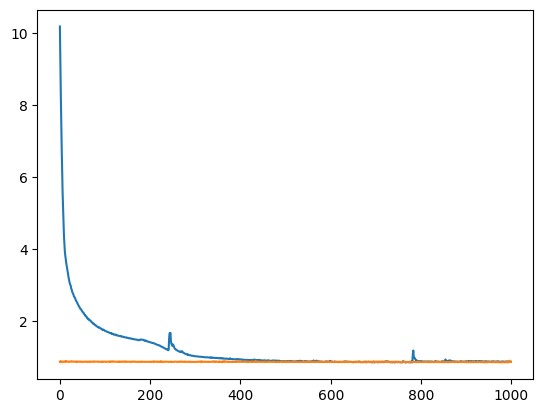

In [22]:
history = model.fit({"inputs": X, "targets": Y}, epochs=int(1e3), verbose=0)
plt.plot(history.history["loss"])

We can now visualise the fit. We clearly see that a single layer GP with a simple stationary kernel has trouble fitting this dataset.

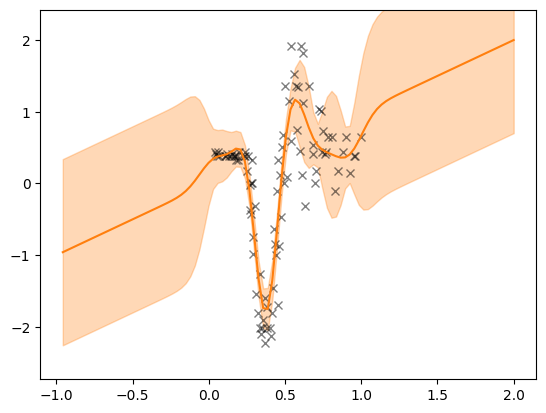

In [23]:
def plot(model, X, Y, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    a = 1.0
    N_test = 100
    X_test = np.linspace(X.min() - a, X.max() + a, N_test).reshape(-1, 1)
    out = model(X_test)

    mu = out.f_mean.numpy().squeeze()
    var = out.f_var.numpy().squeeze()
    X_test = X_test.squeeze()
    lower = mu - 2 * np.sqrt(var)
    upper = mu + 2 * np.sqrt(var)

    ax.set_ylim(Y.min() - 0.5, Y.max() + 0.5)
    ax.plot(X, Y, "kx", alpha=0.5)
    ax.plot(X_test, mu, "C1")

    ax.fill_between(X_test, lower, upper, color="C1", alpha=0.3)


plot(single_layer_dgp.as_prediction_model(), X, Y)

## Two-layer deep Gaussian process
We repeat the exercise but now we build a two-layer model. The setup is very similar apart from the fact that we create two GP layers, and pass them to our DeepGP model as a list.

In [42]:
Z = np.linspace(X.min(), X.max(), num_inducing).reshape(-1, 1)
kernel1 = gpflow.kernels.SquaredExponential()
inducing_variable1 = gpflow.inducing_variables.InducingPoints(Z.copy())
gp_layer1 = gpflux.layers.GPLayer(
    kernel1, inducing_variable1, num_data=num_data, num_latent_gps=output_dim
)

kernel2 = gpflow.kernels.SquaredExponential()
inducing_variable2 = gpflow.inducing_variables.InducingPoints(Z.copy())
gp_layer2 = gpflux.layers.GPLayer(
    kernel2,
    inducing_variable2,
    num_data=num_data,
    num_latent_gps=output_dim,
    mean_function=gpflow.mean_functions.Zero(),
)

likelihood_layer = gpflux.layers.LikelihoodLayer(gpflow.likelihoods.Gaussian(0.1))
two_layer_dgp = gpflux.models.DeepGP([gp_layer1, gp_layer2], likelihood_layer)
model = two_layer_dgp.as_training_model()
model.compile(gpflow.keras.tf_keras.optimizers.Adam(0.01))

/usr/local/lib/python3.11/dist-packages/gpflux/layers/gp_layer.py:175: UserWarning: Beware, no mean function was specified in the construction of the `GPLayer` so the default `gpflow.mean_functions.Identity` is being used. This mean function will only work if the input dimensionality matches the number of latent Gaussian processes in the layer.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gpflux/layers/gp_layer.py:198: UserWarning: Could not verify the compatibility of the `kernel`, `inducing_variable` and `mean_function`. We advise using `gpflux.helpers.construct_*` to create compatible kernels and inducing variables. As `num_latent_gps=1` has been specified explicitly, this will be used to create the `q_mu` and `q_sqrt` parameters.
  warnings.warn(
<ipython-input-42-d15b07238af5>:18: DeprecationWarning: Call to deprecated class TrackableLayer. (GPflux's `TrackableLayer` was prior to TF2.5 used to collect GPflow variables in subclassed layers. As of TF 2.5, `tf.Module` sup

In [44]:
history = model.fit({"inputs": X, "targets": Y}, epochs=int(1e3), verbose=0)

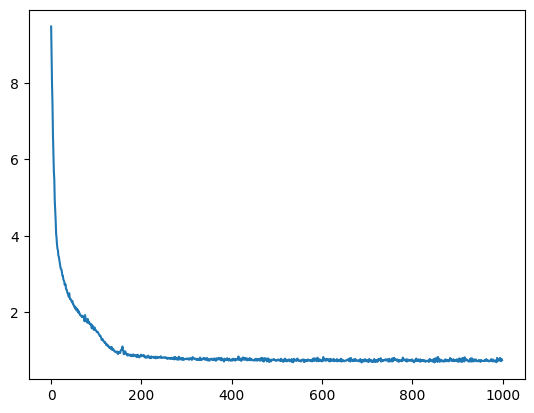

In [45]:
plt.plot(history.history["loss"])

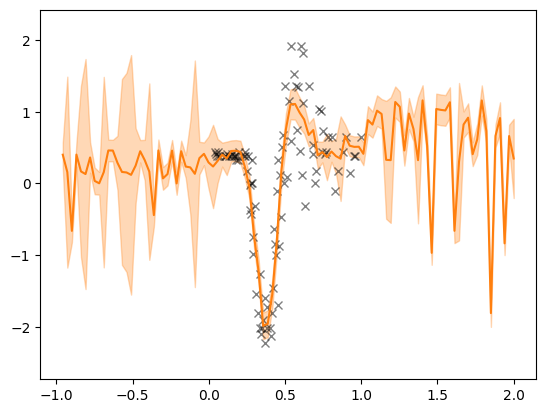

In [46]:
plot(two_layer_dgp.as_prediction_model(), X, Y)

# GPlayer ejemplo smapler

In [47]:
num_data = 200
D = 1
a, b = 0, 1
X = np.linspace(a, b, num_data).reshape(-1, 1)

In [48]:
num_samples = 5

Z = X.copy()
M = Z.shape[0]

# Layer 1
inducing_var1 = construct_basic_inducing_variables(M, D, D, share_variables=True, z_init=Z.copy())
kernel1 = construct_basic_kernel(
    gpflow.kernels.SquaredExponential(lengthscales=0.15),
    output_dim=D,
    share_hyperparams=True,
)
layer1 = GPLayer(kernel1, inducing_var1, num_data, full_cov=True, num_samples=num_samples)

# Layer 2
inducing_var2 = construct_basic_inducing_variables(M, D, D, share_variables=True, z_init=Z.copy())
kernel2 = construct_basic_kernel(
    gpflow.kernels.SquaredExponential(lengthscales=0.8, variance=0.1),
    output_dim=D,
    share_hyperparams=True,
)
layer2 = GPLayer(kernel2, inducing_var2, num_data, full_cov=True, num_samples=num_samples)

# Layer 3
inducing_var3 = construct_basic_inducing_variables(M, D, D, share_variables=True, z_init=Z.copy())
kernel3 = construct_basic_kernel(
    gpflow.kernels.SquaredExponential(lengthscales=0.3, variance=0.1),
    output_dim=D,
    share_hyperparams=True,
)
layer3 = GPLayer(
    kernel3,
    inducing_var3,
    num_data,
    full_cov=True,
    num_samples=num_samples,
    mean_function=gpflow.mean_functions.Zero(),
)

gp_layers = [layer1, layer2, layer3]

In [49]:
#propogating samples throught the layers
layer_input = X
means, covs, samples = [], [], []

for layer in gp_layers:
    layer_output = layer(layer_input)

    mean = layer_output.mean()
    cov = layer_output.covariance()
    sample = tf.convert_to_tensor(layer_output)  # generates num_samples samples...

    layer_input = sample[0]  # for the next layer

    means.append(mean.numpy().T)  # transpose to go from [1, N] to [N, 1]
    covs.append(cov.numpy())
    samples.append(sample.numpy())

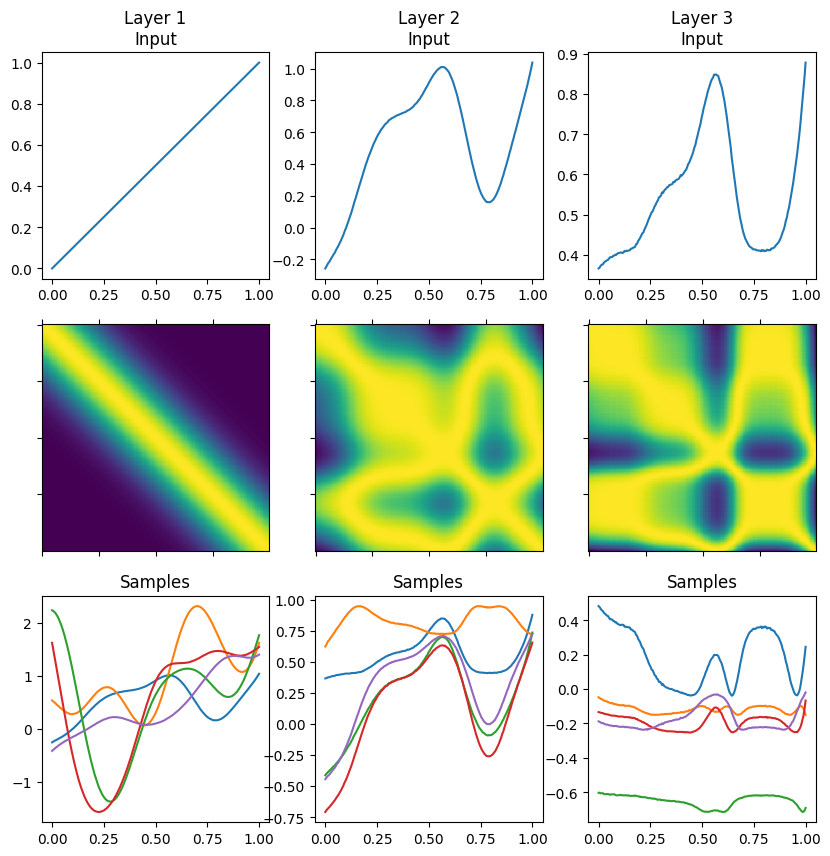

In [50]:
num_layers = len(gp_layers)
fig, axes = plt.subplots(3, num_layers, figsize=(num_layers * 3.33, 10))

for i in range(num_layers):
    layer_input = X if i == 0 else samples[i - 1][0]
    plot_layer(X, layer_input, means[i], covs[i], samples[i], i, axes[:, i])